# Chaotic Delayed Matching Diagnostics

Load the task-trained chaotic delayed matching model, inspect trial-level behavior, and visualize latent activity.

In [42]:
from pathlib import Path
import importlib
import os
import sys
import types

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ctd").exists():
    REPO_ROOT = Path.cwd().parents[0]
os.environ.setdefault("HOME_DIR", str(REPO_ROOT))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

def install_compatibility_stubs():
    if "dotenv" not in sys.modules:
        dotenv_stub = types.ModuleType("dotenv")
        dotenv_stub.load_dotenv = lambda *args, **kwargs: False
        dotenv_stub.find_dotenv = lambda *args, **kwargs: ""
        sys.modules["dotenv"] = dotenv_stub

    if "DSA" not in sys.modules:
        dsa_module = types.ModuleType("DSA")
        dsa_stats = types.ModuleType("DSA.stats")
        dsa_stats.dsa_bw_data_splits = lambda *args, **kwargs: None
        dsa_stats.dsa_to_id = lambda *args, **kwargs: None
        dsa_module.DSA = object
        sys.modules["DSA"] = dsa_module
        sys.modules["DSA.stats"] = dsa_stats

    try:
        import lightning_fabric.utilities.data as lightning_data
        if not hasattr(lightning_data, "AttributeDict"):
            class AttributeDict(dict):
                __getattr__ = dict.get
                __setattr__ = dict.__setitem__
            lightning_data.AttributeDict = AttributeDict
    except Exception:
        pass

    legacy_aliases = {
        "ctd.data_modeling.models.SAE.dyn_models_GRU": "ctd.data_modeling.models.SAE.dyn_models_gru",
    }
    for legacy_name, target_name in legacy_aliases.items():
        if legacy_name not in sys.modules:
            try:
                sys.modules[legacy_name] = importlib.import_module(target_name)
            except Exception:
                pass

install_compatibility_stubs()
torch.set_grad_enabled(False)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Load Model

In [43]:
from ctd.comparison.analysis.tt.tt import Analysis_TT

RUN_PATH = REPO_ROOT / "content" / "trained_models" / "task-trained" / "tt_ChaoticDelayedMatching"
# Alternate trained run with the same hyperparameters:
# RUN_PATH = REPO_ROOT / "content" / "trained_models" / "task-trained" / "20260320_ChaoticDelayedMatching_Final" / "max_epochs=100_recurrent_gain=2.20E+00_batch_size=256_seed=0"

required = ["model.pkl", "datamodule_sim.pkl", "simulator.pkl"]
missing = [name for name in required if not (RUN_PATH / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing} under {RUN_PATH}")

analysis = Analysis_TT(run_name=RUN_PATH.name, filepath=f"{RUN_PATH}/")
analysis.wrapper.eval()
if hasattr(analysis.model, "noise_level"):
    analysis.model.noise_level = 0.0

out = analysis.get_model_outputs(phase="all")
ics, inputs, targets = analysis.get_model_inputs(phase="all")
extra = analysis.get_extra_inputs(phase="all")
latents = analysis.get_latents(phase="all")
controlled = out["controlled"]

print(f"Run path: {RUN_PATH.relative_to(REPO_ROOT)}")
print(f"inputs:     {tuple(inputs.shape)}")
print(f"targets:    {tuple(targets.shape)}")
print(f"controlled: {tuple(controlled.shape)}")
print(f"latents:    {tuple(latents.shape)}")
print(f"extra:      {tuple(extra.shape)}")

Run path: content/trained_models/task-trained/tt_ChaoticDelayedMatching
inputs:     (2000, 1050, 2)
targets:    (2000, 1050, 1)
controlled: (2000, 1050, 1)
latents:    (2000, 1050, 200)
extra:      (2000, 13)


## Response-Window Performance

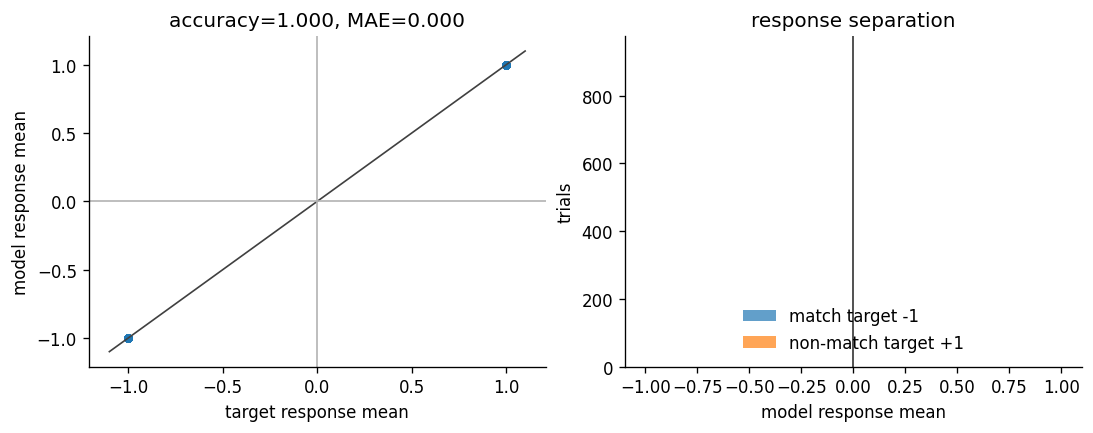

[-0.99990916  0.99990916  0.99990916  0.99990916 -0.99990916 -0.9999088
  0.99990916  0.99990916 -0.99990916 -0.99990916]


In [44]:
def response_window_cols(extra_tensor):
    if extra_tensor.shape[1] >= 13:
        return 8, 9
    if extra_tensor.shape[1] >= 11:
        return 6, 7
    raise ValueError(f"Unsupported extra shape: {tuple(extra_tensor.shape)}")

def response_means(signal, extra_tensor):
    resp_on_col, resp_off_col = response_window_cols(extra_tensor)
    vals = []
    for trial_idx in range(signal.shape[0]):
        start = int(extra_tensor[trial_idx, resp_on_col].item())
        stop = int(extra_tensor[trial_idx, resp_off_col].item())
        vals.append(signal[trial_idx, start:stop, 0].mean().item())
    return np.asarray(vals)

pred_resp = response_means(controlled, extra)
target_resp = response_means(targets, extra)
pred_label = np.where(pred_resp >= 0, 1.0, -1.0)
target_label = np.where(target_resp >= 0, 1.0, -1.0)
accuracy = (pred_label == target_label).mean()
mae = np.abs(pred_resp - target_resp).mean()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].scatter(target_resp, pred_resp, s=14, alpha=0.65)
lims = [min(target_resp.min(), pred_resp.min()) - 0.1, max(target_resp.max(), pred_resp.max()) + 0.1]
axes[0].plot(lims, lims, color="0.25", lw=1)
axes[0].axhline(0, color="0.7", lw=1)
axes[0].axvline(0, color="0.7", lw=1)
axes[0].set(xlabel="target response mean", ylabel="model response mean", title=f"accuracy={accuracy:.3f}, MAE={mae:.3f}")

axes[1].hist(pred_resp[target_label < 0], bins=30, alpha=0.7, label="match target -1")
axes[1].hist(pred_resp[target_label > 0], bins=30, alpha=0.7, label="non-match target +1")
axes[1].axvline(0, color="0.2", lw=1)
axes[1].set(xlabel="model response mean", ylabel="trials", title="response separation")
axes[1].legend(frameon=False)
plt.show()
print(pred_resp[:10])

## Trial Diagnostics

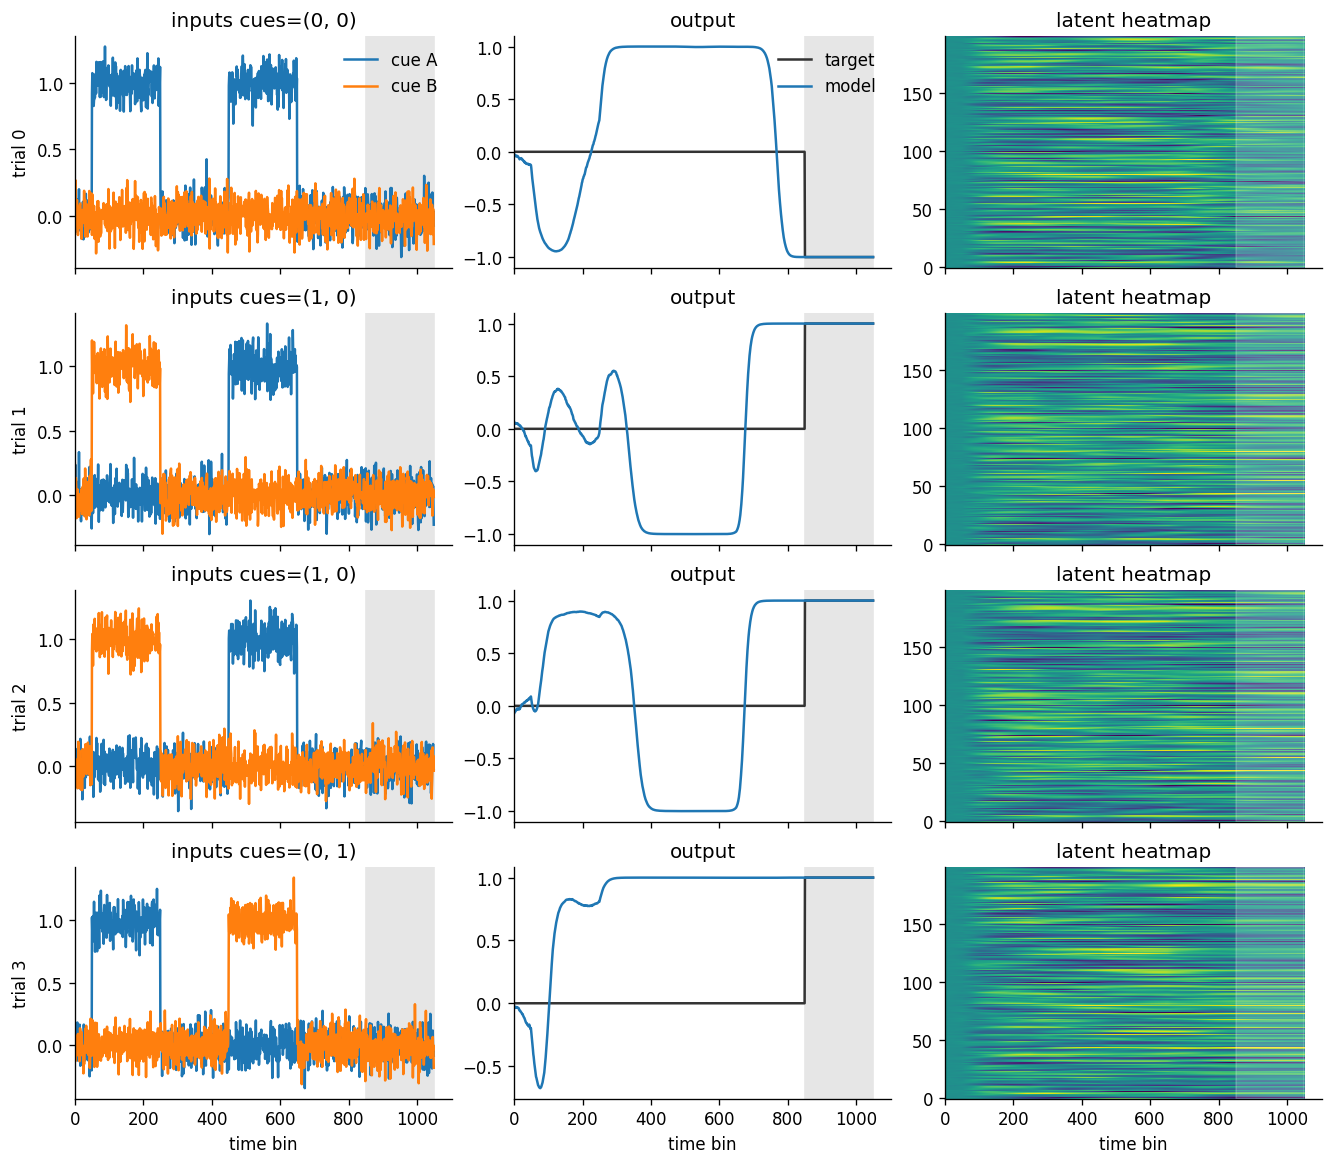

In [45]:
trial_ids = [0, 1, 2, 3]
time = np.arange(inputs.shape[1])
resp_on_col, resp_off_col = response_window_cols(extra)

fig, axes = plt.subplots(len(trial_ids), 3, figsize=(11, 2.4 * len(trial_ids)), sharex=True, constrained_layout=True)
if len(trial_ids) == 1:
    axes = axes[None, :]

for row, trial_idx in enumerate(trial_ids):
    resp_on = int(extra[trial_idx, resp_on_col].item())
    resp_off = int(extra[trial_idx, resp_off_col].item())
    cue_pair = tuple(extra[trial_idx, 10:12].int().tolist()) if extra.shape[1] >= 12 else None
    title_suffix = f" cues={cue_pair}" if cue_pair is not None else ""

    axes[row, 0].plot(time, inputs[trial_idx, :, 0].cpu(), label="cue A")
    axes[row, 0].plot(time, inputs[trial_idx, :, 1].cpu(), label="cue B")
    axes[row, 0].axvspan(resp_on, resp_off, color="0.9", zorder=-1)
    axes[row, 0].set_ylabel(f"trial {trial_idx}")
    axes[row, 0].set_title(f"inputs{title_suffix}")

    axes[row, 1].plot(time, targets[trial_idx, :, 0].cpu(), label="target", color="0.2")
    axes[row, 1].plot(time, controlled[trial_idx, :, 0].cpu(), label="model", color="tab:blue")
    axes[row, 1].axvspan(resp_on, resp_off, color="0.9", zorder=-1)
    axes[row, 1].set_title("output")

    axes[row, 2].imshow(latents[trial_idx].cpu().T, aspect="auto", origin="lower", cmap="viridis")
    axes[row, 2].axvspan(resp_on, resp_off, color="white", alpha=0.18)
    axes[row, 2].set_title("latent heatmap")

for ax in axes[-1, :]:
    ax.set_xlabel("time bin")
axes[0, 0].legend(frameon=False, loc="upper right")
axes[0, 1].legend(frameon=False, loc="upper right")
plt.show()

## Latent PCA

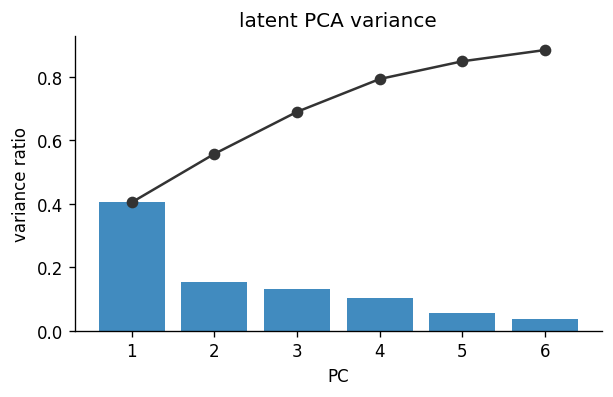

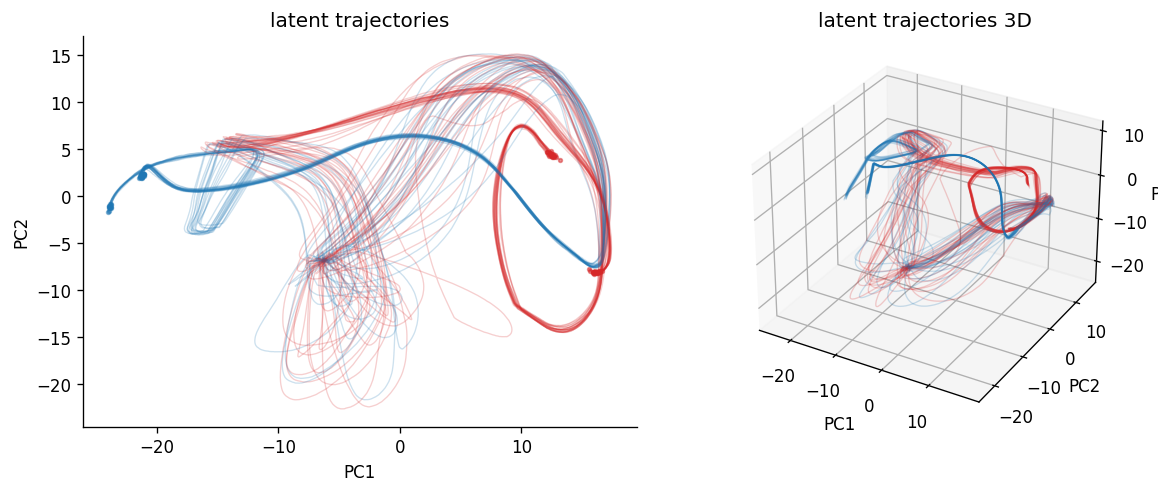

In [46]:
lat_np = latents.detach().cpu().numpy()
n_trials, n_time, n_lat = lat_np.shape
pca = PCA(n_components=6)
lat_pca_flat = pca.fit_transform(lat_np.reshape(-1, n_lat))
lat_pca = lat_pca_flat.reshape(n_trials, n_time, -1)

fig, ax = plt.subplots(figsize=(5, 3.2), constrained_layout=True)
ax.bar(np.arange(1, 7), pca.explained_variance_ratio_, color="tab:blue", alpha=0.85)
ax.plot(np.arange(1, 7), np.cumsum(pca.explained_variance_ratio_), color="0.2", marker="o")
ax.set(xlabel="PC", ylabel="variance ratio", title="latent PCA variance")
plt.show()

colors = np.where(target_label > 0, "tab:red", "tab:blue")
fig = plt.figure(figsize=(10, 4), constrained_layout=True)
ax2 = fig.add_subplot(1, 2, 1)
ax3 = fig.add_subplot(1, 2, 2, projection="3d")
for trial_idx in range(min(80, n_trials)):
    c = colors[trial_idx]
    ax2.plot(lat_pca[trial_idx, :, 0], lat_pca[trial_idx, :, 1], color=c, alpha=0.22, lw=0.8)
    ax2.scatter(lat_pca[trial_idx, -1, 0], lat_pca[trial_idx, -1, 1], color=c, s=5, alpha=0.5)
    ax3.plot(lat_pca[trial_idx, :, 0], lat_pca[trial_idx, :, 1], lat_pca[trial_idx, :, 2], color=c, alpha=0.22, lw=0.8)
ax2.set(xlabel="PC1", ylabel="PC2", title="latent trajectories")
ax3.set(xlabel="PC1", ylabel="PC2", zlabel="PC3", title="latent trajectories 3D")
plt.show()

## Condition Averages

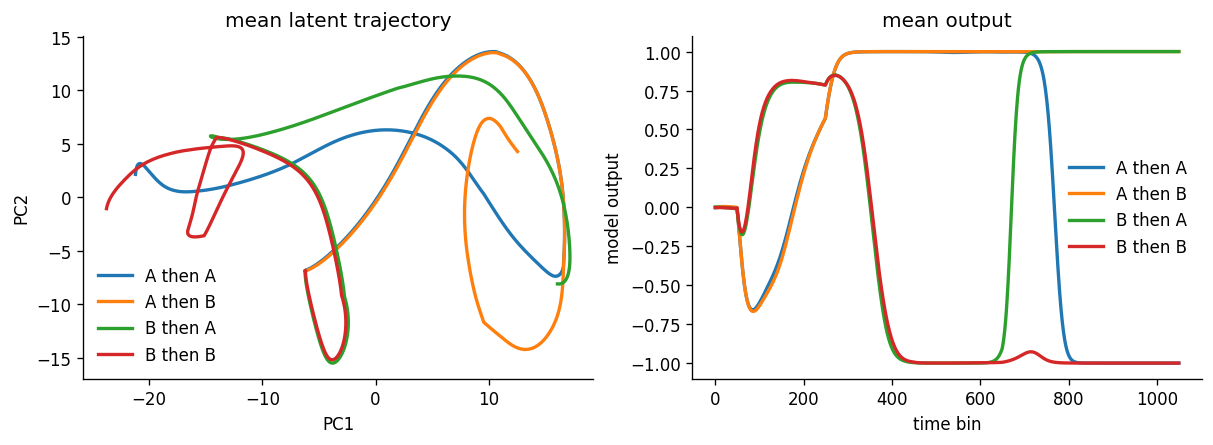

In [47]:
if extra.shape[1] >= 13:
    condition_names = {
        (0, 0): "A then A",
        (0, 1): "A then B",
        (1, 0): "B then A",
        (1, 1): "B then B",
    }
    cue_pairs = extra[:, 10:12].int().cpu().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
    for pair, name in condition_names.items():
        mask = (cue_pairs[:, 0] == pair[0]) & (cue_pairs[:, 1] == pair[1])
        if not mask.any():
            continue
        mean_pc = lat_pca[mask, :, :3].mean(axis=0)
        mean_out = controlled.detach().cpu().numpy()[mask, :, 0].mean(axis=0)
        axes[0].plot(mean_pc[:, 0], mean_pc[:, 1], lw=2, label=name)
        axes[1].plot(mean_out, lw=2, label=name)
    axes[0].set(xlabel="PC1", ylabel="PC2", title="mean latent trajectory")
    axes[1].set(xlabel="time bin", ylabel="model output", title="mean output")
    axes[0].legend(frameon=False)
    axes[1].legend(frameon=False)
    plt.show()
else:
    print("No cue-pair condition columns found in extra.")

## Chaos Diagnostics

Estimate finite-time chaos in the learned recurrent dynamics with local Jacobian Lyapunov spectra, then test how small input perturbations amplify through the learned model.

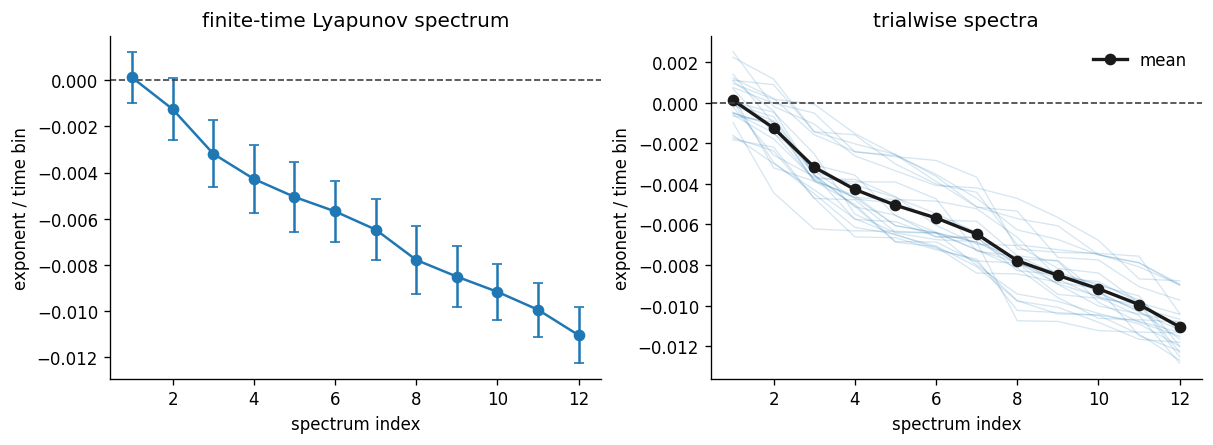

Computed 12 exponents on 24 trials.
Max finite-time Lyapunov exponent: 0.0001
Positive mean exponents: 1/12
Mean spectrum: [ 0.0001 -0.0013 -0.0032 -0.0043 -0.0051 -0.0057 -0.0065 -0.0078 -0.0085
 -0.0092 -0.0100 -0.0111]


In [48]:
from ctd.comparison.metrics import compute_jacobians, compute_lyaps

def hidden_step_factory(model):
    """Return f(u_t, h_t) -> h_{t+1} for the learned recurrent dynamics."""
    def hidden_step(u_t, h_t):
        _, next_h = model(u_t, h_t)
        return next_h
    return hidden_step

LYAP_N_TRIALS = min(24, latents.shape[0])
LYAP_TOP_K = min(12, latents.shape[-1])

device = next(analysis.model.parameters()).device
model_inputs_for_jac = inputs.to(device)
latents_for_jac = latents.to(device)

analysis.wrapper.eval()
noise_level = getattr(analysis.model, "noise_level", None)
if noise_level is not None:
    analysis.model.noise_level = 0.0

try:
    with torch.enable_grad():
        Jz, Ju, lyap_trial_idx = compute_jacobians(
            z=latents_for_jac[:, :-1, :],
            u=model_inputs_for_jac[:, 1:, :],
            f=hidden_step_factory(analysis.model),
            num_trials=LYAP_N_TRIALS,
            seed=0,
        )
        lyap_spectrum = compute_lyaps(Jz, dt=1, k=LYAP_TOP_K).detach().cpu()
finally:
    if noise_level is not None:
        analysis.model.noise_level = noise_level

lyap_mean = lyap_spectrum.mean(dim=0).numpy()
lyap_std = lyap_spectrum.std(dim=0, unbiased=False).numpy()
max_lyap = float(lyap_mean[0])
positive_count = int((lyap_mean > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
idx = np.arange(1, len(lyap_mean) + 1)
axes[0].errorbar(idx, lyap_mean, yerr=lyap_std, marker="o", capsize=3, lw=1.5)
axes[0].axhline(0, color="0.25", lw=1, linestyle="--")
axes[0].set(xlabel="spectrum index", ylabel="exponent / time bin", title="finite-time Lyapunov spectrum")

for row in lyap_spectrum.numpy():
    axes[1].plot(idx, row, color="tab:blue", alpha=0.18, lw=0.8)
axes[1].plot(idx, lyap_mean, color="0.1", marker="o", lw=2, label="mean")
axes[1].axhline(0, color="0.25", lw=1, linestyle="--")
axes[1].set(xlabel="spectrum index", ylabel="exponent / time bin", title="trialwise spectra")
axes[1].legend(frameon=False)
plt.show()

print(f"Computed {LYAP_TOP_K} exponents on {len(lyap_trial_idx)} trials.")
print(f"Max finite-time Lyapunov exponent: {max_lyap:.4f}")
print(f"Positive mean exponents: {positive_count}/{len(lyap_mean)}")
print("Mean spectrum:", np.array2string(lyap_mean, precision=4, floatmode="fixed"))


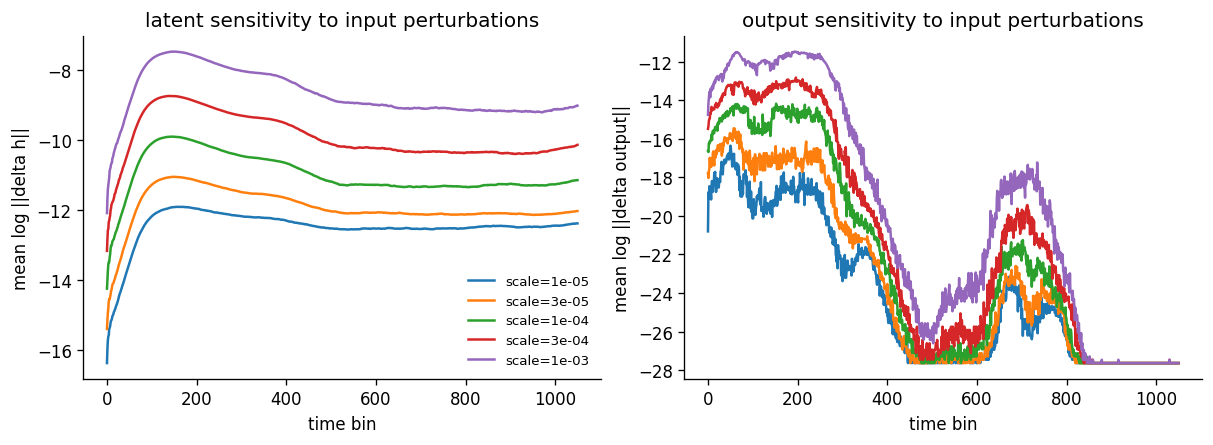

Input perturbation sensitivity summary
scale=1e-05 | latent slope=0.0002 +/- 0.0005 | peak gain=8.52e-01 | final gain=4.48e-01
scale=3e-05 | latent slope=-0.0004 +/- 0.0006 | peak gain=6.79e-01 | final gain=2.15e-01
scale=1e-04 | latent slope=-0.0008 +/- 0.0007 | peak gain=6.55e-01 | final gain=1.64e-01
scale=3e-04 | latent slope=-0.0011 +/- 0.0008 | peak gain=7.46e-01 | final gain=1.58e-01
scale=1e-03 | latent slope=-0.0012 +/- 0.0008 | peak gain=8.03e-01 | final gain=1.42e-01


In [49]:
def rollout_uncoupled_model(model, input_tensor, initial_hidden=None):
    """Roll out the learned recurrent model with fixed initial hidden state."""
    model_device = next(model.parameters()).device
    input_tensor = input_tensor.to(model_device)
    batch_size = input_tensor.shape[0]
    if initial_hidden is None:
        if hasattr(model, "init_hidden"):
            hidden = model.init_hidden(batch_size).to(model_device)
        else:
            hidden = torch.zeros(batch_size, model.latent_size, device=model_device)
    else:
        hidden = initial_hidden.to(model_device).clone()

    outputs = []
    hidden_states = []
    for step_idx in range(input_tensor.shape[1]):
        output, hidden = model(input_tensor[:, step_idx, :], hidden)
        outputs.append(output)
        hidden_states.append(hidden)
    return torch.stack(outputs, dim=1), torch.stack(hidden_states, dim=1)

PERTURB_N_TRIALS = min(64, inputs.shape[0])
PERTURB_SCALES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
PERTURB_SEED = 1

device = next(analysis.model.parameters()).device
base_inputs = inputs[:PERTURB_N_TRIALS].to(device)
model = analysis.model
model.eval()
noise_level = getattr(model, "noise_level", None)
if noise_level is not None:
    model.noise_level = 0.0

gen = torch.Generator(device=device)
gen.manual_seed(PERTURB_SEED)

with torch.no_grad():
    torch.manual_seed(PERTURB_SEED)
    if hasattr(model, "init_hidden"):
        hidden0 = model.init_hidden(base_inputs.shape[0]).to(device)
    else:
        hidden0 = torch.zeros(base_inputs.shape[0], model.latent_size, device=device)

    base_out, base_lat = rollout_uncoupled_model(model, base_inputs, hidden0)
    perturb_results = []
    for scale in PERTURB_SCALES:
        delta_u = torch.randn(base_inputs.shape, generator=gen, device=device)
        delta_u = scale * delta_u / torch.linalg.norm(delta_u.reshape(delta_u.shape[0], -1), dim=1).view(-1, 1, 1).clamp_min(1e-12)
        pert_out, pert_lat = rollout_uncoupled_model(model, base_inputs + delta_u, hidden0)

        latent_delta = torch.linalg.norm(pert_lat - base_lat, dim=-1).clamp_min(1e-12)
        output_delta = torch.linalg.norm(pert_out - base_out, dim=-1).clamp_min(1e-12)
        input_delta = torch.linalg.norm(delta_u.reshape(delta_u.shape[0], -1), dim=1).clamp_min(1e-12)

        x = torch.arange(latent_delta.shape[1], dtype=latent_delta.dtype, device=device).unsqueeze(0)
        x_centered = x - x.mean(dim=1, keepdim=True)
        y_centered = torch.log(latent_delta) - torch.log(latent_delta).mean(dim=1, keepdim=True)
        slopes = (x_centered * y_centered).sum(dim=1) / (x_centered**2).sum(dim=1).clamp_min(1e-12)

        perturb_results.append({
            "scale": scale,
            "mean_log_latent_delta": torch.log(latent_delta).mean(dim=0).cpu().numpy(),
            "std_log_latent_delta": torch.log(latent_delta).std(dim=0, unbiased=False).cpu().numpy(),
            "mean_log_output_delta": torch.log(output_delta).mean(dim=0).cpu().numpy(),
            "gain_final": (latent_delta[:, -1] / input_delta).mean().item(),
            "gain_peak": (latent_delta.max(dim=1).values / input_delta).mean().item(),
            "mean_log_latent_slope": slopes.mean().item(),
            "std_log_latent_slope": slopes.std(unbiased=False).item(),
        })

if noise_level is not None:
    model.noise_level = noise_level

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
time = np.arange(base_inputs.shape[1])
for result in perturb_results:
    label = f"scale={result['scale']:.0e}"
    axes[0].plot(time, result["mean_log_latent_delta"], lw=1.5, label=label)
    axes[1].plot(time, result["mean_log_output_delta"], lw=1.5, label=label)
axes[0].set(xlabel="time bin", ylabel="mean log ||delta h||", title="latent sensitivity to input perturbations")
axes[1].set(xlabel="time bin", ylabel="mean log ||delta output||", title="output sensitivity to input perturbations")
axes[0].legend(frameon=False, fontsize=8)
plt.show()

print("Input perturbation sensitivity summary")
for result in perturb_results:
    print(
        f"scale={result['scale']:.0e} | "
        f"latent slope={result['mean_log_latent_slope']:.4f} +/- {result['std_log_latent_slope']:.4f} | "
        f"peak gain={result['gain_peak']:.2e} | final gain={result['gain_final']:.2e}"
    )


### Example Initial-Condition Perturbed Trials

Plot representative baseline and initial-condition-perturbed rollouts with identical inputs so trajectory divergence reflects sensitivity to the learned recurrent state.

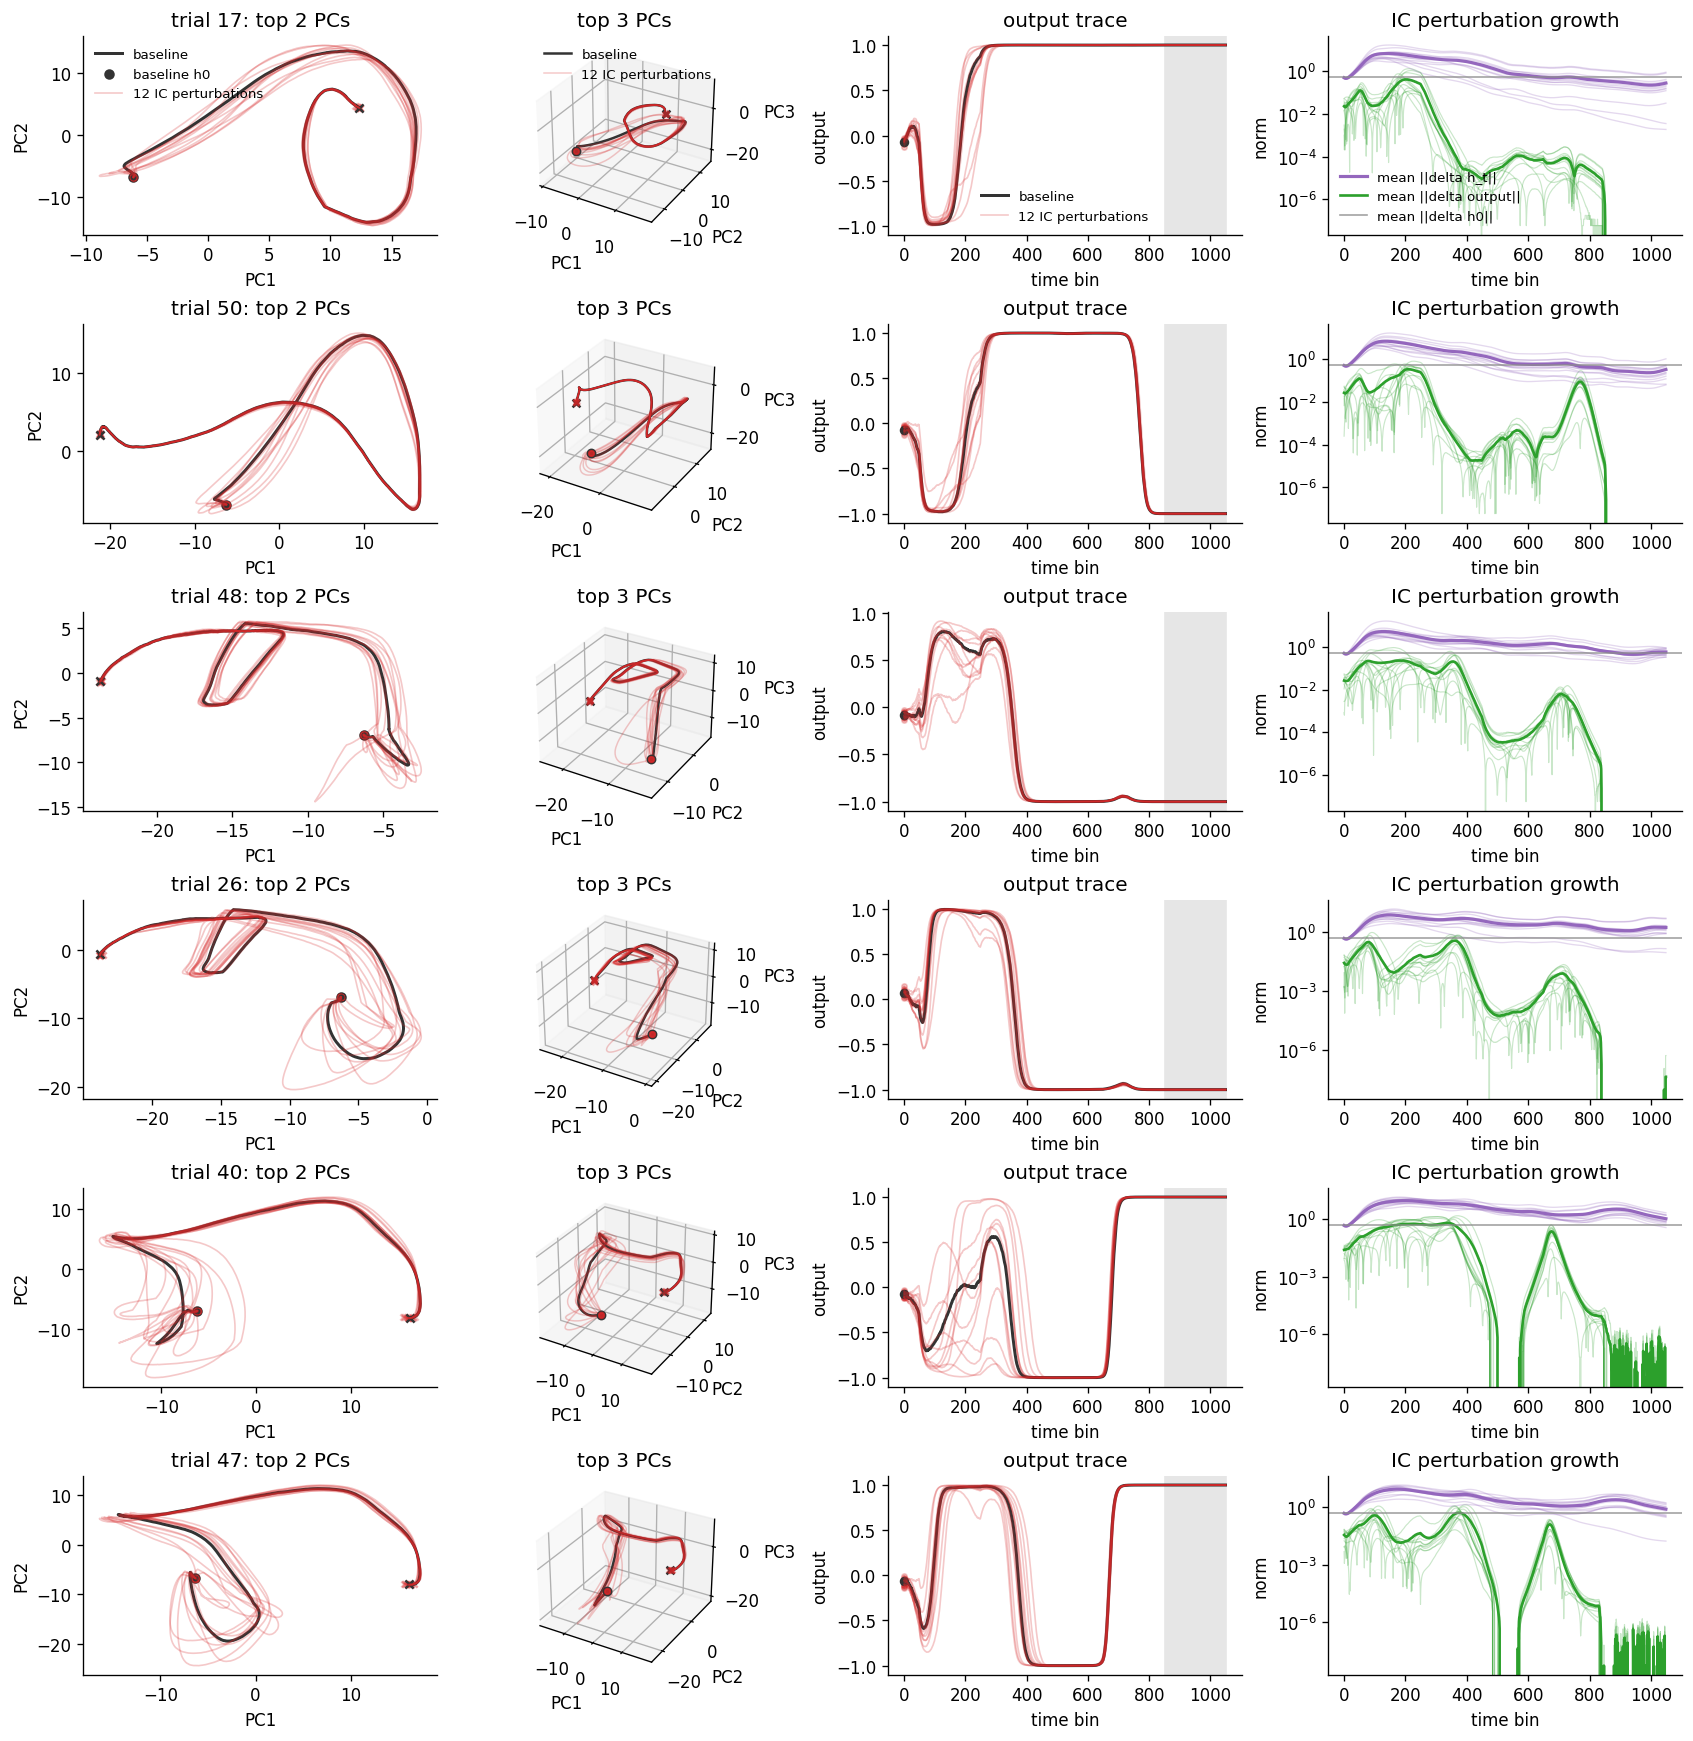

Showing the 6 trials with largest peak latent deviation across 12 initial-condition perturbations at scale 0.5 (random).
Trial ids: [17, 50, 48, 26, 40, 47]
Mean projected h0 offsets in top 2 PCs: [0.0484 0.0571 0.0518 0.0393 0.0505 0.0367]


In [55]:
PLOT_IC_PERTURB_SCALE = 0.5
PLOT_IC_PERTURB_MODE = "random"  # "pc12" samples visible top-PC directions; "random" samples generic high-D directions.
PLOT_N_PERTURBATIONS = 12
PLOT_N_TRIALS = min(6, inputs.shape[0])
PLOT_SEED = 11

device = next(analysis.model.parameters()).device
model = analysis.model
model.eval()
noise_level = getattr(model, "noise_level", None)
if noise_level is not None:
    model.noise_level = 0.0

plot_inputs = inputs[: max(PERTURB_N_TRIALS, PLOT_N_TRIALS)].to(device)
plot_gen = torch.Generator(device=device)
plot_gen.manual_seed(PLOT_SEED)

with torch.no_grad():
    torch.manual_seed(PLOT_SEED)
    if hasattr(model, "init_hidden"):
        plot_hidden0 = model.init_hidden(plot_inputs.shape[0]).to(device)
    else:
        plot_hidden0 = torch.zeros(plot_inputs.shape[0], model.latent_size, device=device)

    n_pert = int(PLOT_N_PERTURBATIONS)
    n_trials_for_plot = plot_inputs.shape[0]
    if PLOT_IC_PERTURB_MODE == "pc12":
        pc_dirs = torch.as_tensor(pca.components_[:2], dtype=plot_hidden0.dtype, device=device)
        theta = torch.linspace(0, 2 * torch.pi, n_pert + 1, device=device)[:-1]
        delta_template = torch.cos(theta)[:, None] * pc_dirs[0] + torch.sin(theta)[:, None] * pc_dirs[1]
        delta_h0_plot = delta_template[:, None, :].expand(n_pert, n_trials_for_plot, -1).clone()
    else:
        delta_h0_plot = torch.randn(
            n_pert,
            n_trials_for_plot,
            plot_hidden0.shape[-1],
            generator=plot_gen,
            device=device,
        )

    delta_h0_plot = PLOT_IC_PERTURB_SCALE * delta_h0_plot / torch.linalg.norm(
        delta_h0_plot, dim=-1, keepdim=True
    ).clamp_min(1e-12)

    base_out_plot, base_lat_plot = rollout_uncoupled_model(model, plot_inputs, plot_hidden0)

    ensemble_inputs = plot_inputs.unsqueeze(0).expand(n_pert, -1, -1, -1).reshape(
        n_pert * n_trials_for_plot, plot_inputs.shape[1], plot_inputs.shape[2]
    )
    ensemble_h0 = (plot_hidden0.unsqueeze(0) + delta_h0_plot).reshape(
        n_pert * n_trials_for_plot, plot_hidden0.shape[-1]
    )
    pert_out_flat, pert_lat_flat = rollout_uncoupled_model(model, ensemble_inputs, ensemble_h0)
    pert_out_plot = pert_out_flat.reshape(n_pert, n_trials_for_plot, *pert_out_flat.shape[1:])
    pert_lat_plot = pert_lat_flat.reshape(n_pert, n_trials_for_plot, *pert_lat_flat.shape[1:])

if noise_level is not None:
    model.noise_level = noise_level

latent_delta_plot = torch.linalg.norm(
    pert_lat_plot - base_lat_plot.unsqueeze(0), dim=-1
).detach().cpu().numpy()
output_delta_plot = torch.linalg.norm(
    pert_out_plot - base_out_plot.unsqueeze(0), dim=-1
).detach().cpu().numpy()
ic_delta_plot = torch.linalg.norm(delta_h0_plot, dim=-1).detach().cpu().numpy()
ranked_trials = np.argsort(latent_delta_plot.max(axis=(0, 2)))[::-1]
example_trials = ranked_trials[:PLOT_N_TRIALS]

base_h0_np = plot_hidden0.detach().cpu().numpy()
pert_h0_np = (plot_hidden0.unsqueeze(0) + delta_h0_plot).detach().cpu().numpy()
base_h0_pc = pca.transform(base_h0_np)
pert_h0_pc = pca.transform(pert_h0_np.reshape(-1, pert_h0_np.shape[-1])).reshape(n_pert, n_trials_for_plot, -1)
base_lat_np = base_lat_plot.detach().cpu().numpy()
pert_lat_np = pert_lat_plot.detach().cpu().numpy()
base_pc_plot = pca.transform(base_lat_np.reshape(-1, base_lat_np.shape[-1])).reshape(base_lat_np.shape[0], base_lat_np.shape[1], -1)
pert_pc_plot = pca.transform(pert_lat_np.reshape(-1, pert_lat_np.shape[-1])).reshape(n_pert, n_trials_for_plot, pert_lat_np.shape[2], -1)
base_out_np = base_out_plot.detach().cpu().numpy()
pert_out_np = pert_out_plot.detach().cpu().numpy()

fig = plt.figure(figsize=(14, 2.4 * PLOT_N_TRIALS), constrained_layout=True)
axes = np.empty((PLOT_N_TRIALS, 4), dtype=object)
for row in range(PLOT_N_TRIALS):
    axes[row, 0] = fig.add_subplot(PLOT_N_TRIALS, 4, row * 4 + 1)
    axes[row, 1] = fig.add_subplot(PLOT_N_TRIALS, 4, row * 4 + 2, projection="3d")
    axes[row, 2] = fig.add_subplot(PLOT_N_TRIALS, 4, row * 4 + 3)
    axes[row, 3] = fig.add_subplot(PLOT_N_TRIALS, 4, row * 4 + 4)

time = np.arange(plot_inputs.shape[1])
pert_alpha = min(0.75, max(0.12, 3.0 / max(n_pert, 1)))
for row, trial_idx in enumerate(example_trials):
    resp_on = int(extra[trial_idx, resp_on_col].item()) if trial_idx < extra.shape[0] else None
    resp_off = int(extra[trial_idx, resp_off_col].item()) if trial_idx < extra.shape[0] else None

    axes[row, 0].plot(base_pc_plot[trial_idx, :, 0], base_pc_plot[trial_idx, :, 1], color="0.2", lw=1.8, label="baseline")
    axes[row, 0].scatter(base_h0_pc[trial_idx, 0], base_h0_pc[trial_idx, 1], color="0.2", marker="o", s=28, label="baseline h0")
    for pert_idx in range(n_pert):
        label = f"{n_pert} IC perturbations" if pert_idx == 0 else None
        axes[row, 0].plot(pert_pc_plot[pert_idx, trial_idx, :, 0], pert_pc_plot[pert_idx, trial_idx, :, 1], color="tab:red", lw=1.0, alpha=pert_alpha, label=label)
        axes[row, 0].scatter(pert_h0_pc[pert_idx, trial_idx, 0], pert_h0_pc[pert_idx, trial_idx, 1], color="tab:red", marker="o", s=12, alpha=pert_alpha)
        axes[row, 0].scatter(pert_pc_plot[pert_idx, trial_idx, -1, 0], pert_pc_plot[pert_idx, trial_idx, -1, 1], color="tab:red", marker="x", s=14, alpha=pert_alpha)
    axes[row, 0].scatter(base_pc_plot[trial_idx, 0, 0], base_pc_plot[trial_idx, 0, 1], color="0.2", marker=".", s=28)
    axes[row, 0].scatter(base_pc_plot[trial_idx, -1, 0], base_pc_plot[trial_idx, -1, 1], color="0.2", marker="x", s=24)
    axes[row, 0].set(xlabel="PC1", ylabel="PC2", title=f"trial {trial_idx}: top 2 PCs")

    axes[row, 1].plot(base_pc_plot[trial_idx, :, 0], base_pc_plot[trial_idx, :, 1], base_pc_plot[trial_idx, :, 2], color="0.2", lw=1.5, label="baseline")
    axes[row, 1].scatter(base_h0_pc[trial_idx, 0], base_h0_pc[trial_idx, 1], base_h0_pc[trial_idx, 2], color="0.2", marker="o", s=24)
    for pert_idx in range(n_pert):
        label = f"{n_pert} IC perturbations" if pert_idx == 0 else None
        axes[row, 1].plot(pert_pc_plot[pert_idx, trial_idx, :, 0], pert_pc_plot[pert_idx, trial_idx, :, 1], pert_pc_plot[pert_idx, trial_idx, :, 2], color="tab:red", lw=0.9, alpha=pert_alpha, label=label)
        axes[row, 1].scatter(pert_h0_pc[pert_idx, trial_idx, 0], pert_h0_pc[pert_idx, trial_idx, 1], pert_h0_pc[pert_idx, trial_idx, 2], color="tab:red", marker="o", s=10, alpha=pert_alpha)
        axes[row, 1].scatter(pert_pc_plot[pert_idx, trial_idx, -1, 0], pert_pc_plot[pert_idx, trial_idx, -1, 1], pert_pc_plot[pert_idx, trial_idx, -1, 2], color="tab:red", marker="x", s=12, alpha=pert_alpha)
    axes[row, 1].scatter(base_pc_plot[trial_idx, -1, 0], base_pc_plot[trial_idx, -1, 1], base_pc_plot[trial_idx, -1, 2], color="0.2", marker="x", s=22)
    axes[row, 1].set(xlabel="PC1", ylabel="PC2", zlabel="PC3", title="top 3 PCs")

    axes[row, 2].plot(time, base_out_np[trial_idx, :, 0], color="0.2", lw=1.8, label="baseline")
    for pert_idx in range(n_pert):
        label = f"{n_pert} IC perturbations" if pert_idx == 0 else None
        axes[row, 2].plot(time, pert_out_np[pert_idx, trial_idx, :, 0], color="tab:red", lw=1.0, alpha=pert_alpha, label=label)
        axes[row, 2].scatter(time[0], pert_out_np[pert_idx, trial_idx, 0, 0], color="tab:red", s=10, alpha=pert_alpha)
    axes[row, 2].scatter(time[0], base_out_np[trial_idx, 0, 0], color="0.2", s=22)
    if resp_on is not None:
        axes[row, 2].axvspan(resp_on, resp_off, color="0.9", zorder=-1)
    axes[row, 2].set(xlabel="time bin", ylabel="output", title="output trace")

    for pert_idx in range(n_pert):
        axes[row, 3].plot(time, latent_delta_plot[pert_idx, trial_idx], color="tab:purple", lw=0.8, alpha=pert_alpha)
        axes[row, 3].plot(time, output_delta_plot[pert_idx, trial_idx], color="tab:green", lw=0.7, alpha=pert_alpha)
    axes[row, 3].plot(time, latent_delta_plot[:, trial_idx].mean(axis=0), color="tab:purple", lw=1.9, label="mean ||delta h_t||")
    axes[row, 3].plot(time, output_delta_plot[:, trial_idx].mean(axis=0), color="tab:green", lw=1.6, label="mean ||delta output||")
    axes[row, 3].axhline(ic_delta_plot[:, trial_idx].mean(), color="0.55", lw=1.0, alpha=0.8, label="mean ||delta h0||")
    axes[row, 3].set_yscale("log")
    axes[row, 3].set(xlabel="time bin", ylabel="norm", title="IC perturbation growth")

axes[0, 0].legend(frameon=False, loc="best", fontsize=8)
axes[0, 1].legend(frameon=False, loc="best", fontsize=8)
axes[0, 2].legend(frameon=False, loc="best", fontsize=8)
axes[0, 3].legend(frameon=False, loc="best", fontsize=8)
plt.show()

pc_offset = np.linalg.norm(pert_h0_pc[:, example_trials, :2] - base_h0_pc[example_trials][None, :, :2], axis=2)
print(
    f"Showing the {PLOT_N_TRIALS} trials with largest peak latent deviation across "
    f"{n_pert} initial-condition perturbations at scale {PLOT_IC_PERTURB_SCALE:.2g} ({PLOT_IC_PERTURB_MODE})."
)
print("Trial ids:", example_trials.tolist())
print("Mean projected h0 offsets in top 2 PCs:", np.array2string(pc_offset.mean(axis=0), precision=4, floatmode="fixed"))
